# Phase 3 Step 3: Real-World Dataset Risk Scoring & Decision Layer
## Statlog (German Credit Data) — PD Estimation, Internal Risk Score & Decisioning
### Credit Risk & Loan Decision Intelligence Platform

---

## SECTION 1 — Architecture & Core Principles

In an operational lending workflow, raw machine learning predictions are translated into business decisions through a structured decision layer:

```
Estimated Probability of Default (PD)
               ↓
Internal Demonstration Risk Score (0–100)
               ↓
Policy Risk Tier (LOW / MEDIUM / HIGH)
               ↓
Operational Decision (APPROVE / MANUAL REVIEW / REJECT)
```

### Critical Governance Disclaimers:
1. **Estimated PD**: Model output $P(y=1|X)$ represents an estimated Probability of Default. It is not labeled as a formally calibrated PD (such as from isotonic regression or Platt scaling).
2. **DEMO / INTERNAL RISK SCORE**: The derived formula `risk_score = (1 - estimated_pd) * 100` is an internal demonstration score. It is **NOT** a bureau score (CIBIL / Experian / FICO) or an official credit score.
3. **DEMO POLICY ASSUMPTIONS**: Policy thresholds (`TIER_LOW_MAX_PD = 0.20`, `TIER_MEDIUM_MAX_PD = 0.45`) are configurable demonstration assumptions for illustration, not derived from real commercial banking economics.
4. **Architectural Separation**: Identity risk (PAN / KYC / fraud checks) gates the application before credit default modeling. The German Credit benchmark dataset contains credit features only.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Libraries imported successfully.")

Libraries imported successfully.


---
## SECTION 2 — Data Preparation & Model Fitting

We fit the benchmark Logistic Regression model on $X_{train}$ and generate predictions on $X_{test}$.

In [2]:
data_path = '../data/raw/german_credit_1000.csv' if os.path.exists('../data/raw/german_credit_1000.csv') else 'data/raw/german_credit_1000.csv'
df = pd.read_csv(data_path)

X = df.drop(columns=['default'])
y = df['default']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Fit benchmark model
model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_processed, y_train)

# Generate estimated PD on untouched test set
estimated_pd = model.predict_proba(X_test_processed)[:, 1]
print("Estimated PD successfully generated for test partition.")

Estimated PD successfully generated for test partition.


---
## SECTION 3 — Derive Internal Demonstration Risk Score

We derive the internal demonstration risk score:
$$\text{risk\_score} = (1 - \text{estimated\_pd}) \times 100$$
Higher scores indicate higher creditworthiness (lower default propensity).

In [3]:
risk_scores = (1 - estimated_pd) * 100

scoring_df = pd.DataFrame({
    'actual_default': y_test.values,
    'estimated_pd': np.round(estimated_pd, 4),
    'internal_risk_score': np.round(risk_scores, 2)
})

print("Sample Test Records with Internal Risk Scores:")
display(scoring_df.head(10))

Sample Test Records with Internal Risk Scores:


,actual_default,estimated_pd,internal_risk_score
0,0,0.2268,77.32
1,0,0.1015,89.85
2,1,0.6188,38.12
3,0,0.4934,50.66
4,1,0.1502,84.98
5,0,0.1126,88.74
6,0,0.2167,78.33
7,0,0.1133,88.67
8,0,0.4886,51.14
9,0,0.1506,84.94


---
## SECTION 4 — Configurable Policy Thresholds (Demo Policy Assumptions)

We establish configurable named policy constants.

In [4]:
# CONFIGURABLE DEMONSTRATION POLICY THRESHOLDS
TIER_LOW_MAX_PD = 0.20       # PD <= 0.20  --> Risk Score >= 80.0  --> LOW RISK
TIER_MEDIUM_MAX_PD = 0.45    # PD <= 0.45  --> Risk Score >= 55.0  --> MEDIUM RISK
                             # PD >  0.45  --> Risk Score <  55.0  --> HIGH RISK

def assign_risk_tier(pd_val):
    if pd_val <= TIER_LOW_MAX_PD:
        return 'LOW'
    elif pd_val <= TIER_MEDIUM_MAX_PD:
        return 'MEDIUM'
    else:
        return 'HIGH'

def assign_decision(tier):
    if tier == 'LOW':
        return 'APPROVE'
    elif tier == 'MEDIUM':
        return 'MANUAL REVIEW'
    else:
        return 'REJECT'

scoring_df['risk_tier'] = scoring_df['estimated_pd'].apply(assign_risk_tier)
scoring_df['decision'] = scoring_df['risk_tier'].apply(assign_decision)

print("Scoring DataFrame with Policy Tiers & Decisions:")
display(scoring_df.head(10))

Scoring DataFrame with Policy Tiers & Decisions:


,actual_default,estimated_pd,internal_risk_score,risk_tier,decision
0,0,0.2268,77.32,MEDIUM,MANUAL REVIEW
1,0,0.1015,89.85,LOW,APPROVE
2,1,0.6188,38.12,HIGH,REJECT
3,0,0.4934,50.66,HIGH,REJECT
4,1,0.1502,84.98,LOW,APPROVE
5,0,0.1126,88.74,LOW,APPROVE
6,0,0.2167,78.33,MEDIUM,MANUAL REVIEW
7,0,0.1133,88.67,LOW,APPROVE
8,0,0.4886,51.14,HIGH,REJECT
9,0,0.1506,84.94,LOW,APPROVE


---
## SECTION 5 — Decision Distribution & Portfolio Breakdown

We analyze the operational volume across decision categories.

Decision Volume Summary (Test Partition):


,Decision,Applicant Count,Proportion (%)
0,APPROVE,91,45.5
1,REJECT,58,29.0
2,MANUAL REVIEW,51,25.5


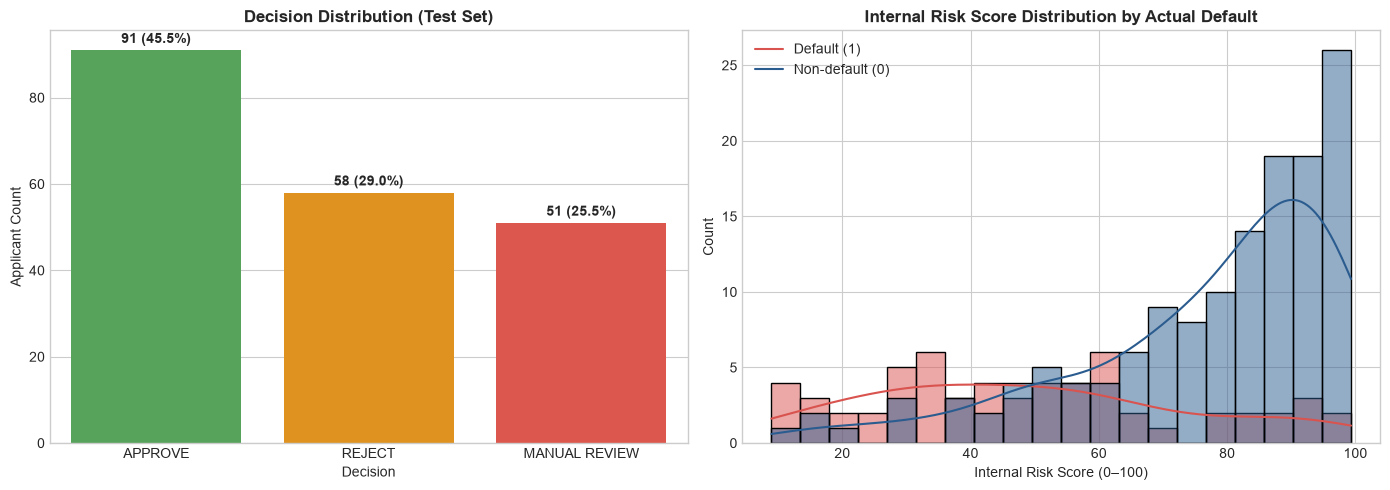

In [5]:
decision_counts = scoring_df['decision'].value_counts()
decision_pcts = (decision_counts / len(scoring_df)) * 100

decision_summary = pd.DataFrame({
    'Decision': decision_counts.index,
    'Applicant Count': decision_counts.values,
    'Proportion (%)': decision_pcts.values
})
print("Decision Volume Summary (Test Partition):")
display(decision_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision distribution bar chart
sns.barplot(data=decision_summary, x='Decision', y='Applicant Count', ax=axes[0], palette=['#4caf50', '#ff9800', '#f44336'])
axes[0].set_title('Decision Distribution (Test Set)', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())} ({p.get_height()/len(scoring_df)*100:.1f}%)",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

# Internal score distribution by actual outcome
sns.histplot(data=scoring_df, x='internal_risk_score', hue='actual_default', kde=True, ax=axes[1], palette=['#2b5c8f', '#d9534f'], bins=20)
axes[1].set_title('Internal Risk Score Distribution by Actual Default', fontweight='bold')
axes[1].set_xlabel('Internal Risk Score (0–100)')
axes[1].legend(['Default (1)', 'Non-default (0)'])

plt.tight_layout()
plt.show()

---
## SECTION 6 — Decision Quality & Default Rate Audit

We audit the empirical default rate within each decision category to evaluate portfolio safety.

In [6]:
policy_audit = scoring_df.groupby('decision').agg(
    total_applicants=('actual_default', 'count'),
    actual_defaults=('actual_default', 'sum'),
    default_rate=('actual_default', 'mean'),
    avg_risk_score=('internal_risk_score', 'mean'),
    avg_estimated_pd=('estimated_pd', 'mean')
).reset_index()

policy_audit['default_rate_pct'] = policy_audit['default_rate'] * 100
policy_audit = policy_audit.sort_values(by='avg_estimated_pd')

print("Policy Quality & Default Rate Audit:")
display(policy_audit[['decision', 'total_applicants', 'actual_defaults', 'default_rate_pct', 'avg_risk_score', 'avg_estimated_pd']].round(2))

Policy Quality & Default Rate Audit:


,decision,total_applicants,actual_defaults,default_rate_pct,avg_risk_score,avg_estimated_pd
0,APPROVE,91,10,10.99,90.84,0.09
1,MANUAL REVIEW,51,14,27.45,67.71,0.32
2,REJECT,58,36,62.07,34.73,0.65


---
## SECTION 7 — Architectural Boundary Audit

### Identity Risk vs. Credit Default Risk
1. **Flow A (Identity Risk Gate)**: Evaluates identity consistency, PAN verification, Aadhaar KYC, and anti-fraud rules *prior* to underwriting.
2. **Flow B (Credit Default Risk)**: Ingests validated financial and credit profile attributes to output estimated PD.
3. **Authenticity Guarantee**: In accordance with project governance, no synthetic Indian PAN/KYC flags have been added to the German Credit dataset.

---
## SECTION 8 — Automated Validation Gates

We execute 10 programmatic validation checks.

In [7]:
print("Running Phase 3 Risk Scoring Automated Validation Gates...")

# Gate 1: Scoring dataframe row count
assert len(scoring_df) == len(X_test), "Scoring dataframe length mismatch!"
print("  ✓ Gate 1: Scoring dataframe length matches test set.")

# Gate 2: Estimated PD strictly in [0.0, 1.0]
assert (scoring_df['estimated_pd'] >= 0.0).all() and (scoring_df['estimated_pd'] <= 1.0).all(), "Estimated PD out of range!"
print("  ✓ Gate 2: Estimated PD bounded strictly in [0.0, 1.0].")

# Gate 3: Internal risk score strictly in [0.0, 100.0]
assert (scoring_df['internal_risk_score'] >= 0.0).all() and (scoring_df['internal_risk_score'] <= 100.0).all(), "Risk score out of range!"
print("  ✓ Gate 3: Internal risk scores bounded strictly in [0.0, 100.0].")

# Gate 4: Monotonic score formula risk_score == (1 - pd) * 100
recalc_scores = (1 - scoring_df['estimated_pd']) * 100
assert np.allclose(scoring_df['internal_risk_score'], recalc_scores, atol=0.01), "Risk score formula mismatch!"
print("  ✓ Gate 4: Score derivation formula risk_score = (1 - pd) * 100 confirmed.")

# Gate 5: Valid risk tier categories
assert set(scoring_df['risk_tier'].unique()).issubset({'LOW', 'MEDIUM', 'HIGH'}), "Invalid risk tiers found!"
print("  ✓ Gate 5: Valid risk tier assignments (LOW, MEDIUM, HIGH) confirmed.")

# Gate 6: Valid decision categories
assert set(scoring_df['decision'].unique()).issubset({'APPROVE', 'MANUAL REVIEW', 'REJECT'}), "Invalid decisions found!"
print("  ✓ Gate 6: Valid decision assignments confirmed.")

# Gate 7: LOW tier maps strictly to APPROVE
low_decisions = scoring_df[scoring_df['risk_tier'] == 'LOW']['decision'].unique()
assert len(low_decisions) == 0 or set(low_decisions) == {'APPROVE'}, "LOW tier mapping error!"
print("  ✓ Gate 7: LOW tier maps exclusively to APPROVE.")

# Gate 8: MEDIUM tier maps strictly to MANUAL REVIEW
med_decisions = scoring_df[scoring_df['risk_tier'] == 'MEDIUM']['decision'].unique()
assert len(med_decisions) == 0 or set(med_decisions) == {'MANUAL REVIEW'}, "MEDIUM tier mapping error!"
print("  ✓ Gate 8: MEDIUM tier maps exclusively to MANUAL REVIEW.")

# Gate 9: HIGH tier maps strictly to REJECT
high_decisions = scoring_df[scoring_df['risk_tier'] == 'HIGH']['decision'].unique()
assert len(high_decisions) == 0 or set(high_decisions) == {'REJECT'}, "HIGH tier mapping error!"
print("  ✓ Gate 9: HIGH tier maps exclusively to REJECT.")

# Gate 10: Zero NaNs across scoring output
assert not scoring_df.isnull().any().any(), "NaN values found in scoring dataframe!"
print("  ✓ Gate 10: Zero NaNs in scoring outputs confirmed.")

print("\n" + "="*60)
print("ALL 10 PHASE 3 RISK SCORING VALIDATION GATES PASSED!")
print("="*60)

Running Phase 3 Risk Scoring Automated Validation Gates...
  ✓ Gate 1: Scoring dataframe length matches test set.
  ✓ Gate 2: Estimated PD bounded strictly in [0.0, 1.0].
  ✓ Gate 3: Internal risk scores bounded strictly in [0.0, 100.0].
  ✓ Gate 4: Score derivation formula risk_score = (1 - pd) * 100 confirmed.
  ✓ Gate 5: Valid risk tier assignments (LOW, MEDIUM, HIGH) confirmed.
  ✓ Gate 6: Valid decision assignments confirmed.
  ✓ Gate 7: LOW tier maps exclusively to APPROVE.
  ✓ Gate 8: MEDIUM tier maps exclusively to MANUAL REVIEW.
  ✓ Gate 9: HIGH tier maps exclusively to REJECT.
  ✓ Gate 10: Zero NaNs in scoring outputs confirmed.

ALL 10 PHASE 3 RISK SCORING VALIDATION GATES PASSED!
